# Customer Segmentation Using RFM and K-Means

### Business objective
The goal is to group customers with similar purchasing behaviour so the business can design more targeted marketing strategies.

### Method in simple terms
- **Customer segmentation** groups customers with similar behaviour.
- **RFM analysis** describes each customer using:
  - **Recency:** how recently the customer purchased.
  - **Frequency:** how many unique orders the customer made.
  - **Monetary:** how much the customer spent.
- **K-Means clustering** groups customers based on their RFM profiles. Customers in the same cluster have similar purchasing patterns.


### Libraries Importation

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import plotly.colors
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style = "whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

### Data Importation and Profiling

In [3]:
file_path = "OnlineRetail.xlsx"
excel_file = pd.ExcelFile(file_path)

In [4]:
data = pd.read_excel(file_path, sheet_name = excel_file.sheet_names[0])
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [5]:
data.shape

(541909, 8)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# missing values, duplicates, uniqueness and data coverage
audit_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Exact duplicate rows",
        "Unique invoices",
        "Unique products",
        "Unique customers (excluding missing)",
        "Missing CustomerID rows",
        "Missing Description rows",
        "Minimum InvoiceDate",
        "Maximum InvoiceDate",
        "Negative Quantity rows",
        "Zero Quantity rows",
        "Negative UnitPrice rows",
        "Zero UnitPrice rows"
    ],
    "Value": [
        len(data), 
        data.shape[1],
        data.duplicated().sum(),
        data["InvoiceNo"].nunique(),
        data["StockCode"].nunique(),
        data["CustomerID"].nunique(dropna = True), 
        data["CustomerID"].isna().sum(), 
        data["Description"].isna().sum(),
        data["InvoiceDate"].min(),
        data["InvoiceDate"].max(),
        (data["Quantity"] < 0).sum(),
        (data["Quantity"] == 0).sum(),
       (data["UnitPrice"] > 0).sum(),
        (data["UnitPrice"] == 0).sum(),
    ]
    
})
display(audit_summary)

,Metric,Value
0,Rows,541909
1,Columns,8
2,Exact duplicate rows,5268
3,Unique invoices,25900
4,Unique products,4070
5,Unique customers (excluding missing),4372
6,Missing CustomerID rows,135080
7,Missing Description rows,1454
8,Minimum InvoiceDate,2010-12-01 08:26:00
9,Maximum InvoiceDate,2011-12-09 12:50:00


### Audit Summary

The dataset contains **541,909 rows and 8 columns**, covering transactions from **December 2010 to December 2011**. The audit identified **5,268 exact duplicate rows**, **135,080 rows with missing CustomerID**, and **1,454 rows with missing product descriptions**. There were also **10,624 negative-quantity transactions** and **2,515 zero-price transactions**, which may represent returns, cancellations, or adjustments. These data-quality issues were considered during the cleaning stage before performing the RFM analysis.


In [9]:
# Investigating invoice 
data["InvoicePrefix"] = data["InvoiceNo"].astype(str).str[:1]
display(data["InvoicePrefix"].value_counts().to_frame("Rows"))

,Rows
InvoicePrefix,
5,532618
C,9288
A,3


### Invoice Prefix Analysis

The invoice prefix analysis shows that most transactions have no letter prefix, while **C** represents cancelled invoices and **A** represents a small number of adjustment records. These prefixes were reviewed to identify non-standard transactions before filtering the dataset for RFM analysis.

In [10]:
cleaned_data = data.copy()

In [11]:
cleaned_data = cleaned_data.dropna(subset = ["Description", "CustomerID"])

In [12]:
cleaned_data.duplicated().sum()

np.int64(5225)

In [13]:
cleaned_data = cleaned_data.drop_duplicates()

In [14]:
# Keep positive purchase quantities and positive price, this exclude cancellation and adjustment rows.
purchase_data = cleaned_data[
    (cleaned_data["Quantity"] > 0) & (cleaned_data["UnitPrice"] > 0) 
    # Select rows where the invoice does not start with C
    & (~cleaned_data["InvoiceNo"].astype(str).str.startswith("C"))
]

### Transaction Filtering

Cancellations and transactions with negative or zero quantities and prices were removed to ensure that the analysis reflects valid completed purchases. Including these records could distort customer spending, purchase frequency, and RFM metrics by treating returns, cancellations, or adjustment transactions as genuine purchases.

In [15]:
purchase_data["CustomerID"] = purchase_data["CustomerID"].astype("int")

In [16]:
purchase_data["InvoiceDate"] = pd.to_datetime(purchase_data["InvoiceDate"])

In [17]:
purchase_data["Revenue"] = purchase_data["Quantity"] * purchase_data["UnitPrice"]

In [18]:
purchase_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePrefix,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,5,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,5,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,5,20.34


In [19]:
print(f"Final customers: {purchase_data['CustomerID'].nunique():,}")
print(f"Final unique purchase invoices: {purchase_data['InvoiceNo'].nunique():,}")
print(f"Final unique products: {purchase_data['StockCode'].nunique():,}")
print(f"Purchase date range: {purchase_data['InvoiceDate'].min()} to {purchase_data['InvoiceDate'].max()}")

Final customers: 4,338
Final unique purchase invoices: 18,532
Final unique products: 3,665
Purchase date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## Exploratory Data Analysis

In [20]:
# Average purchase value
# Average amount spent per transaction/invoice
avg_purchase_value = purchase_data.groupby("InvoiceNo")["Revenue"].sum().mean()
print(f"Average purchase value is {avg_purchase_value:,.2f}")

Average purchase value is 479.56


In [21]:
customer_metric = purchase_data.groupby("CustomerID").agg(
    AveragePurchaseValue = ("Revenue", "mean"),
    PurchaseFrequency = ("InvoiceNo", "nunique"), # Number of unique purchases/invoices
    CustomerLifetimeValue = ("Revenue", "sum") # total amount spent
)
customer_metric.head()

,AveragePurchaseValue,PurchaseFrequency,CustomerLifetimeValue
CustomerID,,,
12346,"77,183.60",1,"77,183.60"
12347,23.68,7,"4,310.00"
12348,57.98,4,"1,797.24"
12349,24.08,1,"1,757.55"
12350,19.67,1,334.40


In [22]:
purchase_data[["Quantity", "UnitPrice", "UnitPrice"]].describe()

,Quantity,UnitPrice,UnitPrice
count,"392,692.00","392,692.00","392,692.00"
mean,13.12,3.13,3.13
std,180.49,22.24,22.24
min,1.00,0.00,0.00
25%,2.00,1.25,1.25
50%,6.00,1.95,1.95
75%,12.00,3.75,3.75
max,"80,995.00","8,142.75","8,142.75"


In [23]:
### Trend Analysis
purchase_data["YearMonth"] = purchase_data["InvoiceDate"].dt.to_period("M").astype(str)
purchase_data["YearMonth"].head()

0    2010-12
1    2010-12
2    2010-12
3    2010-12
4    2010-12
Name: YearMonth, dtype: str

In [24]:
monthly_summary = purchase_data.groupby("YearMonth").agg(
    Revenue = ("Revenue", "sum"),
    Transactions = ("InvoiceNo", "nunique"),
    Customers = ("CustomerID", "nunique")
).reset_index()
monthly_summary

,YearMonth,Revenue,Transactions,Customers
0,2010-12,"570,422.73",1400,885
1,2011-01,"568,101.31",987,741
2,2011-02,"446,084.92",997,758
3,2011-03,"594,081.76",1321,974
4,2011-04,"468,374.33",1149,856
5,2011-05,"677,355.15",1555,1056
6,2011-06,"660,046.05",1393,991
7,2011-07,"598,962.90",1331,949
8,2011-08,"644,051.04",1280,935
9,2011-09,"950,690.20",1755,1266


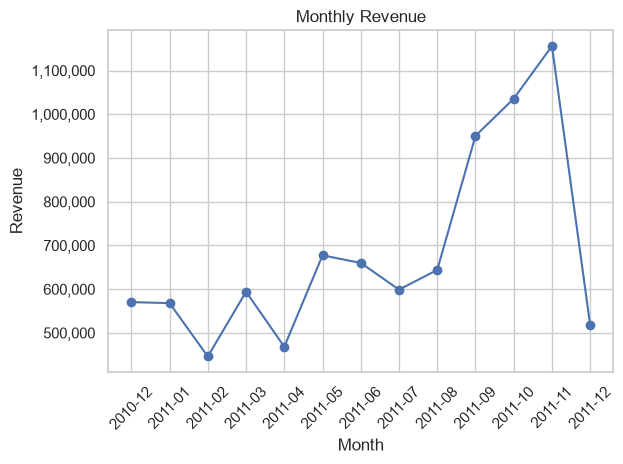

In [25]:
plt.plot(monthly_summary["YearMonth"], monthly_summary["Revenue"], marker = "o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tick_params(axis = "x", rotation = 45)
plt.tight_layout()
plt.show()

### RFM Analysis

In [26]:
reference_today = pd.Timestamp.today().normalize()
reference_today

Timestamp('2026-10-06 00:00:00')

In [27]:
reference_date = purchase_data["InvoiceDate"].max() + pd.Timedelta(days = 1)
reference_date

Timestamp('2011-12-10 12:50:00')

Reference Date: Since the dataset represents historical transactions, the reference date was defined as one day after the latest transaction date in the dataset. This provides an appropriate cutoff point for calculating customer recency without introducing bias from the current date.

In [28]:
# Creating RFM features
rfm = purchase_data.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    MonetaryValue = ("Revenue", "sum")
)
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346,326,1,"77,183.60"
12347,2,7,"4,310.00"
12348,75,4,"1,797.24"
12349,19,1,"1,757.55"
12350,310,1,334.40


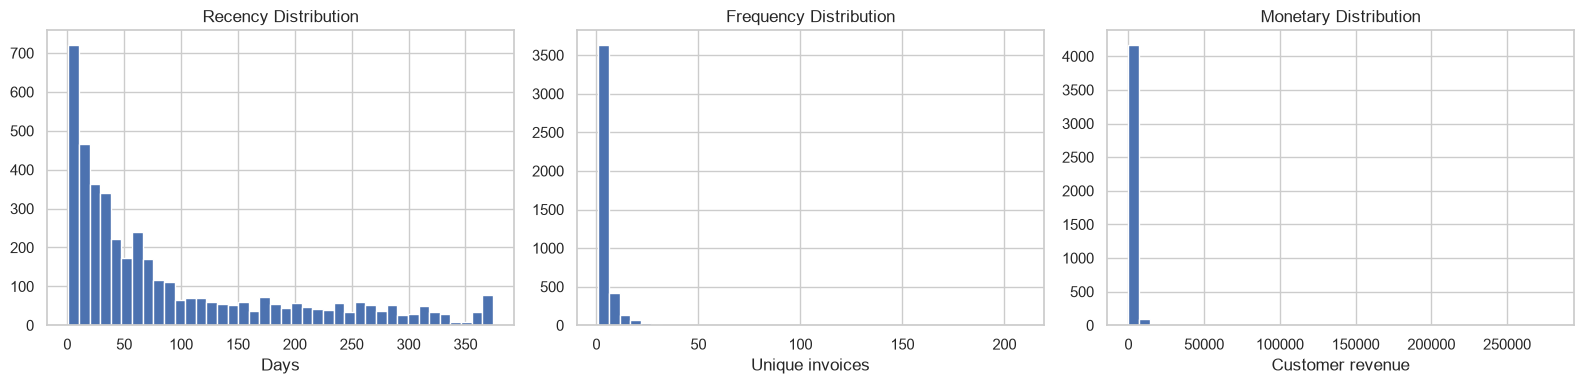

In [29]:
# Customer-level distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins = 40)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")

axes[1].hist(rfm["Frequency"], bins = 40)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Unique invoices")

axes[2].hist(rfm["MonetaryValue"], bins = 40)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Customer revenue")

plt.tight_layout()
plt.show()

##  RFM Distribution & Outliers

The customer-level RFM distributions are strongly right-skewed, especially Frequency and Monetary. A small number of customers have many more orders or much higher spending than the typical customer.


### Feature Transformation and Scaling

In [30]:
# Applying log transformation to reduce the effect of skewedness.
rfm_features = rfm[["Recency", "Frequency", "MonetaryValue"]]
log_rfm_features = np.log1p(rfm_features)

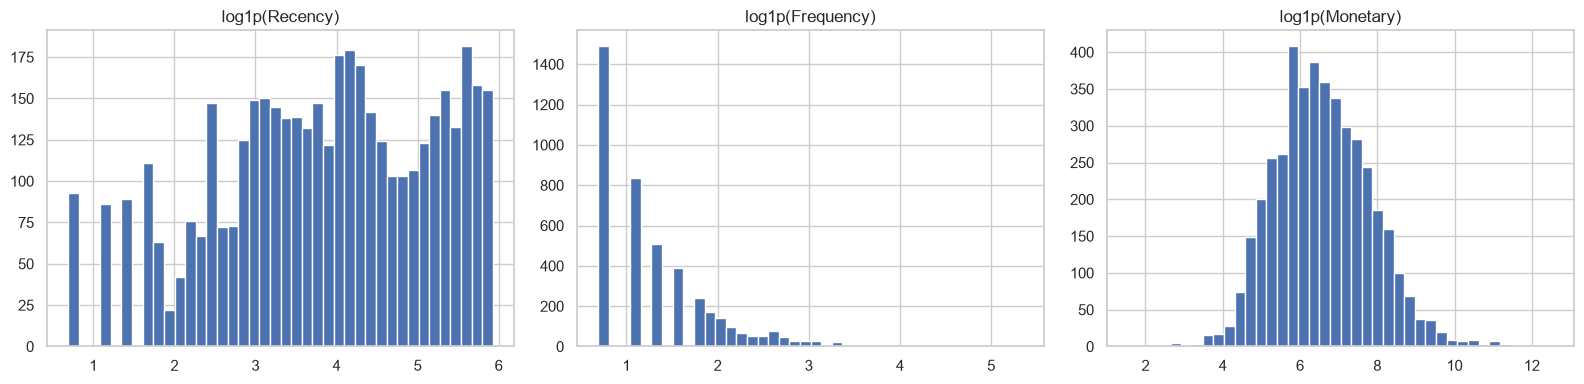

In [31]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

axes[0].hist(log_rfm_features["Recency"], bins = 40)
axes[0].set_title("log1p(Recency)")

axes[1].hist(log_rfm_features["Frequency"], bins = 40)
axes[1].set_title("log1p(Frequency)")

axes[2].hist(log_rfm_features["MonetaryValue"], bins = 40)
axes[2].set_title("log1p(Monetary)")

plt.tight_layout()
plt.show()


In [32]:
scaler = StandardScaler()
scaled_rfm_features = scaler.fit_transform(log_rfm_features)

In [33]:
scaled_rfm_df = pd.DataFrame(scaled_rfm_features, 
                             columns = ["Recency_scaled", "Frequency_scaled", "Monetary_scaled"])

In [34]:
print("Means after scaling:")
display(scaled_rfm_df.mean().to_frame("Mean"))

print("Standard deviations after scaling:")
display(scaled_rfm_df.std(ddof = 0).to_frame("Standard Deviation"))

Means after scaling:


,Mean
Recency_scaled,-0.00
Frequency_scaled,-0.00
Monetary_scaled,-0.00


Standard deviations after scaling:


,Standard Deviation
Recency_scaled,1.00
Frequency_scaled,1.00
Monetary_scaled,1.00


Now we have the mean of 0 and std of 1

### Elbow Method

In [35]:
def evaluate_kmeans_clusters(data, min_k = 2, max_k = 10):
    """
    Evaluate different K-Means cluster counts using
    inertia and silhouette score.
    """
    cluster_evaluation = []
    kmeans_models = {}

    for k in range(min_k, max_k + 1):

        kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 20)
        cluster_labels = kmeans.fit_predict(data)

        cluster_evaluation.append({
            "K": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(data, cluster_labels)
        })

        kmeans_models[k] = kmeans
    cluster_evaluation = pd.DataFrame(cluster_evaluation)

    # Select K with the highest silhouette score
    best_k = int(
        cluster_evaluation.loc[
            cluster_evaluation["Silhouette"].idxmax(), "K"])
    return cluster_evaluation, kmeans_models, best_k

In [36]:
# Evaluate K values from 2 to 10
cluster_evaluation, kmeans_models, best_k = evaluate_kmeans_clusters(
    scaled_rfm_features, min_k = 2, max_k = 10)

display(cluster_evaluation)
print(f"Best K based on silhouette score: {best_k}")

,K,Inertia,Silhouette
0,2,"6,483.59",0.43
1,3,"4,869.49",0.34
2,4,"3,938.60",0.34
3,5,"3,296.71",0.32
4,6,"2,855.53",0.31
5,7,"2,548.82",0.31
6,8,"2,336.34",0.30
7,9,"2,156.01",0.28
8,10,"2,000.57",0.28


Best K based on silhouette score: 2


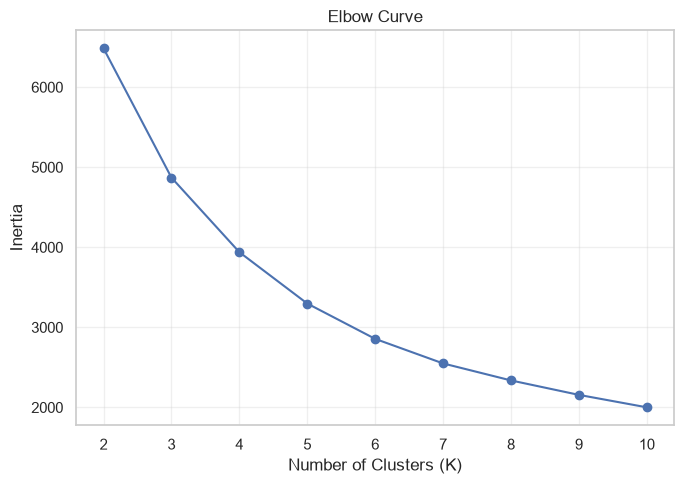

In [37]:
# Elbow curve
plt.figure(figsize = (7, 5))

plt.plot(
    cluster_evaluation["K"], cluster_evaluation["Inertia"], marker = "o")

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(cluster_evaluation["K"])
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

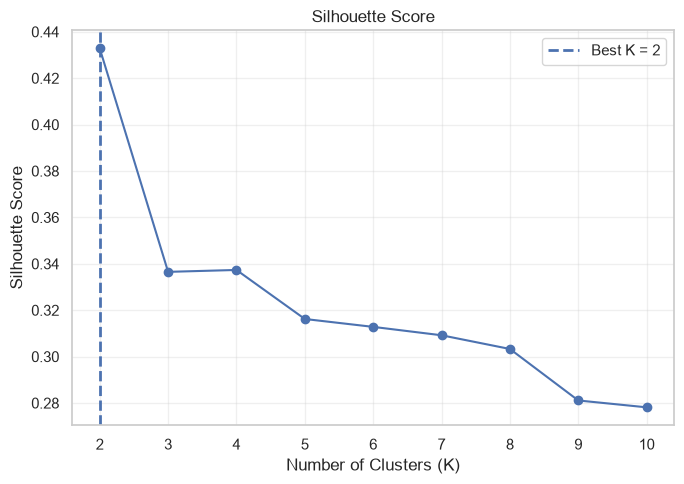

In [38]:
# Silhouette curve
plt.figure(figsize=(7, 5))
plt.plot(cluster_evaluation["K"], cluster_evaluation["Silhouette"], marker = "o")
plt.axvline(best_k, linestyle="--", linewidth = 2,
    label=f"Best K = {best_k}")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_evaluation["K"])
plt.grid(True, alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

Both the Silhouette Score and Elbow Method indicated that the optimal number of clusters is two (k = 2).